# Librerías

In [52]:
import struct
import os
# Manejo de datos
import pandas as pd
import numpy as np


# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Optuna
import optuna

# Preprocesamiento de datos
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

# Copy
import copy

# Manejo de desbalance de clases
from imblearn.over_sampling import SMOTE


# Construcción de la Red Neuronal (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F


# Métricas de evaluación
from sklearn.metrics import (confusion_matrix, classification_report,accuracy_score)

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Verificar si hay GPU disponible para PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Librerías importadas. PyTorch utilizará el dispositivo: {device}")

Librerías importadas. PyTorch utilizará el dispositivo: cpu


# Importar imágenes

In [53]:
def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        # Leer encabezado: numero magico, cantidad, filas, columnas
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        assert magic == 2051, f"Numero magico invalido: {magic}"
        # Leer todos los pixeles y convertir a numpy
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows, cols)
        return images
def load_mnist_labels(filepath):
    with open(filepath, 'rb') as f:
# Leer encabezado: numero magico y cantidad de etiquetas
        magic, num_labels = struct.unpack('>II', f.read(8))
        assert magic == 2049, f"Numero magico invalido: {magic}"
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

base_path = "datasets"
X_train = load_mnist_images(os.path.join(base_path, "train-images.idx3-ubyte"))
y_train = load_mnist_labels(os.path.join(base_path, "train-labels.idx1-ubyte"))
X_test = load_mnist_images(os.path.join(base_path, "t10k-images.idx3-ubyte"))
y_test = load_mnist_labels(os.path.join(base_path, "t10k-labels.idx1-ubyte"))

print(f"X_train: {X_train.shape}") # (60000, 28, 28)
print(f"X_test: {X_test.shape}") # (10000, 28, 28)

X_train: (60000, 28, 28)
X_test: (10000, 28, 28)


In [54]:
# (60000, 28, 28) -> (60000, 784)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"X_train_flat: {X_train_flat.shape}") 
print(f"X_test_flat: {X_test_flat.shape}") 

X_train_flat: (60000, 784)
X_test_flat: (10000, 784)


## Normalización

In [55]:
# Tomamos una muestra para el histograma 'antes'
muestra_antes = X_train_flat[0]

# 2. Normalización al rango [0, 1]
X_train_norm = X_train_flat.astype(np.float32) / 255.0
X_test_norm = X_test_flat.astype(np.float32) / 255.0

# Tomamos una muestra para el histograma 'después'
muestra_despues = X_train_norm[0]

# 3. Etiquetas a formato de PyTorch (enteros largos)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"Forma original: {X_train.shape}")
print(f"Forma aplanada: {X_train_flat.shape}")

Forma original: (60000, 28, 28)
Forma aplanada: (60000, 784)


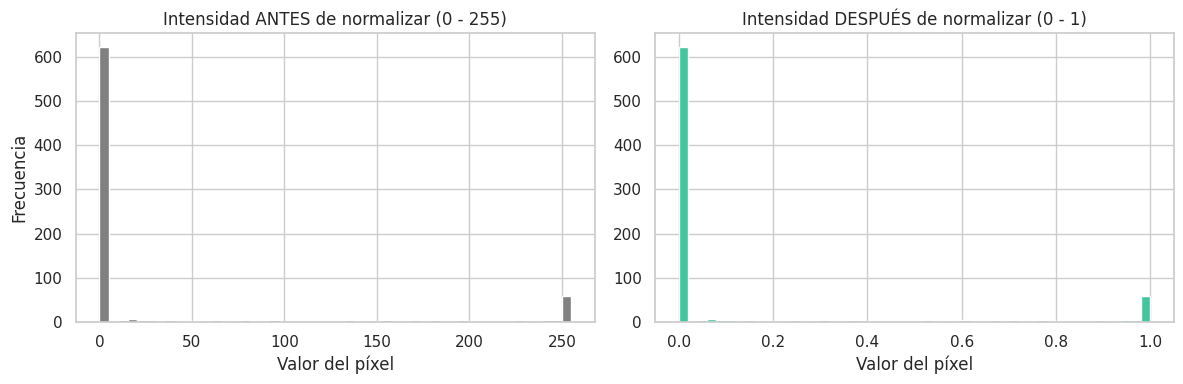

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma Antes
axes[0].hist(muestra_antes, bins=50, color='gray')
axes[0].set_title('Intensidad ANTES de normalizar (0 - 255)')
axes[0].set_xlabel('Valor del píxel')
axes[0].set_ylabel('Frecuencia')

# Histograma Después
axes[1].hist(muestra_despues, bins=50, color='#43C59E')
axes[1].set_title('Intensidad DESPUÉS de normalizar (0 - 1)')
axes[1].set_xlabel('Valor del píxel')

plt.tight_layout()
plt.show()

Como se ve en el gráfico de arriba, los valores fueron normalizados, llevando el rango de píxeles de [0,255] a [0,1]. Esto es fundamental para mejorar la estabilidad numérica en el entrenamiento, evitando que valores muy grandes generen variaciones bruscas del gradiente. 

## One-Hot Encoding

In [57]:
def one_hot_encode(labels, num_classes=10):
    """Convierte etiquetas 0-9 en vectores one-hot de longitud 10."""
    return np.eye(num_classes)[labels]

y_train_onehot = one_hot_encode(y_train)
y_test_onehot = one_hot_encode(y_test)

print(f"y_train_onehot: {y_train_onehot.shape}") # (60000, 10)
print(f"y_test_onehot: {y_test_onehot.shape}") # (10000, 10)
N_CLASES = y_train_onehot.shape[1]

y_train_onehot: (60000, 10)
y_test_onehot: (10000, 10)


## Visualización

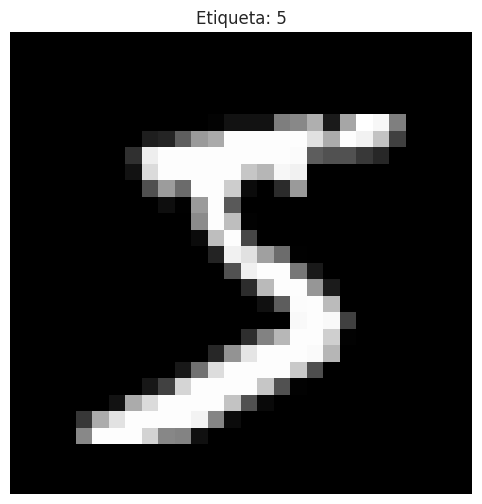

In [58]:
# Visualizar una imagen individual
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis('off')
plt.show()

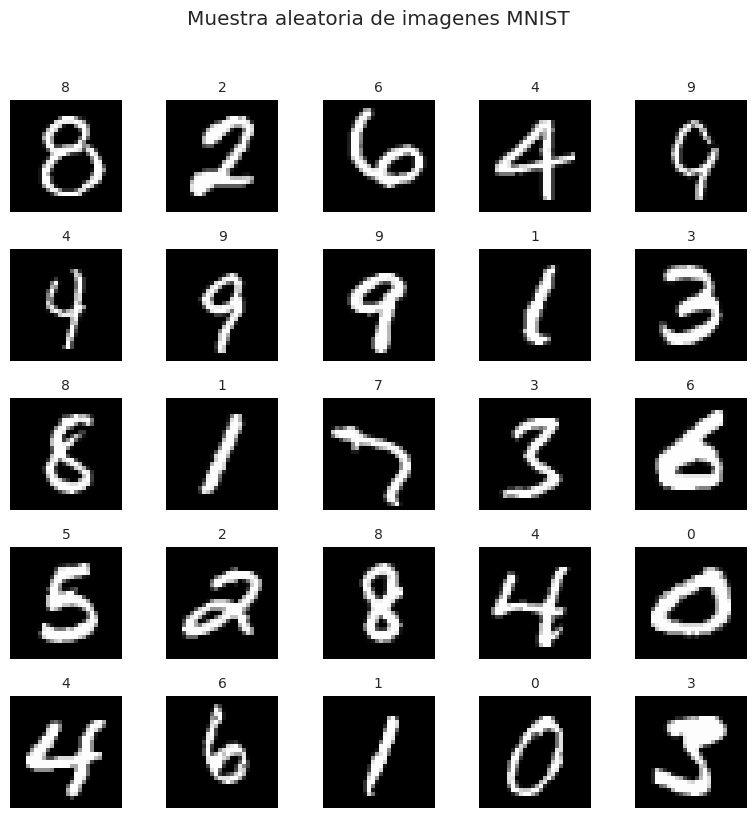

In [59]:
# Visualizar una grilla de 5x5 imagenes aleatorias
indices = np.random.choice(len(X_train), 25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for ax, idx in zip(axes.flat, indices):
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(y_train[idx], fontsize=10)
    ax.axis('off')
plt.suptitle("Muestra aleatoria de imagenes MNIST", y=1.02)
plt.tight_layout()
plt.show()

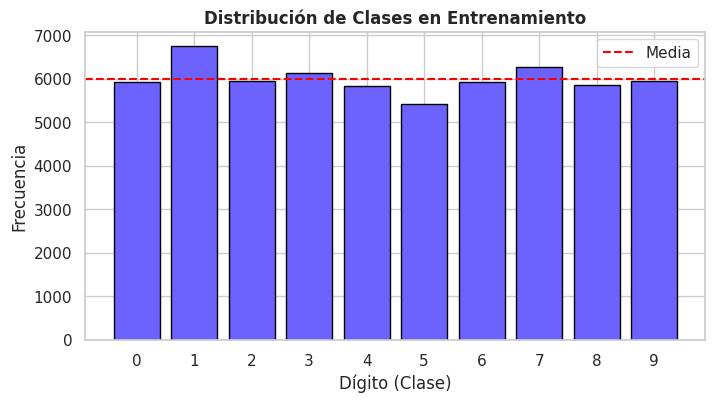

In [60]:
clases, frecuencias = np.unique(y_train_tensor, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(clases, frecuencias, color='#6C63FF', edgecolor='black')
plt.xticks(clases)
plt.title("Distribución de Clases en Entrenamiento", fontsize=12, fontweight='bold')
plt.xlabel("Dígito (Clase)")
plt.ylabel("Frecuencia")
plt.axhline(frecuencias.mean(), color='red', linestyle='--', label='Media')
plt.legend()
plt.show()

In [61]:
# Conclusión impresa sobre el balance
desviacion_maxima = (frecuencias.max() - frecuencias.min()) / frecuencias.mean() * 100
print(f"La variación máxima entre la clase más y menos frecuente es de solo {desviacion_maxima:.1f}%.")

La variación máxima entre la clase más y menos frecuente es de solo 22.0%.


Si bien el dataset tiene ciertos desbalances y algunas clases predominantes (como el 7), la diferencia en cantidad de muestras no es lo suficientemente significativa como para que sea un problema preocupante a la hora de realizar el entrenamiento. 

Al convertir las etiquetas a tensores de tipo long, cada etiqueta se representa con un único valor escalar (por ejemplo, 0‑9 para MNIST). Esta representación es mucho más económica en memoria, porque PyTorch almacena únicamente un vector de enteros en vez de una matriz dispersa de tamaño batch × n_clases. Además, el criterio de pérdida estándar para clasificación multiclase, CrossEntropyLoss, espera precisamente etiquetas enteras y combina internamente el softmax y la pérdida de entropía cruzada, evitando la necesidad de crear explícitamente los vectores one‑hot. De este modo se reduce la sobrecarga de cómputo y se simplifica el pipeline de entrenamiento sin perder ninguna información útil para el modelo.

In [62]:
# 3. Etiquetas a formato de PyTorch (enteros largos)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"Forma original: {y_train_onehot.shape}")
print(f"Forma aplanada: {y_train_tensor.shape}")

Forma original: (60000, 10)
Forma aplanada: torch.Size([60000])


# Definición de la red y el entrenamiento

In [63]:
def entrenar_pytorch_clasificacion(modelo, X_train, y_train, X_test, y_test,
                                    epochs=200,
                                    batch_size=32, lr=1e-3,
                                    weight_decay=1e-4, patience=20):
    """
    Función de entrenamiento para clasificación.
    El parámetro es_binario controla dos cosas que difieren entre ambos casos:
      1. El dtype del tensor de etiquetas (float32 para binaria, long para multiclase)
      2. La función de costo (BCEWithLogitsLoss vs. CrossEntropyLoss)
    Todo lo demás (el loop, el early stopping, los optimizadores) es idéntico.
    """

    # Conversión de numpy arrays a tensores PyTorch 
    X_tr = torch.tensor(X_train, dtype=torch.float32)  # features de train
    X_te = torch.tensor(X_test,  dtype=torch.float32)  # features de test

    # Multiclase: las etiquetas son índices enteros (0, 1, 2...)
    y_tr = torch.tensor(y_train, dtype=torch.long)
    y_te = torch.tensor(y_test,  dtype=torch.long)

    # CrossEntropyLoss = Softmax interna + CCE (Categorical Cross-Entropy)
    criterio = nn.CrossEntropyLoss()

    # Configuración del data loader. 
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

    # Configuración de optimizador
    optimizador = optim.Adam(modelo.parameters(), lr=lr, weight_decay=weight_decay)

    # Variables de seguimiento del entrenamiento 
    historial = {'train_loss': [], 'test_loss': []}
    # mejor_loss: la menor pérdida de test vista hasta ahora
    mejor_loss  = float('inf')   # inf: cualquier pérdida real será menor
    # mejor_pesos: copia del state_dict cuando la pérdida de test fue mínima
    mejor_pesos = None
    # espera: contador de épocas sin mejora (para early stopping)
    espera      = 0

    print(f"\n Entrenando (PyTorch) | epochs={epochs} | batch={batch_size} | lr={lr}")

    for epoca in range(epochs):
        # FASE DE ENTRENAMIENTO
        modelo.train()
        train_loss = 0.0

        for Xb, yb in loader:
            # Forward pass
            pred = modelo(Xb)   # logits, forma (batch_size,) o (batch_size, N)

            # Calcular la pérdida del batch
            loss = criterio(pred, yb)

            # Limpiar gradientes acumulados del paso anterior
            optimizador.zero_grad()

            # Backward pass
            loss.backward()

            # Actualizar pesos
            # optimizer.step() aplica: θ ← θ - lr · grad (con correcciones Adam)
            optimizador.step()

            # Acumulación de la pérdida para promediarla al final de la época
            train_loss += loss.item()

        # Pérdida promedio sobre todos los batches de esta época
        train_loss /= len(loader)

        # Evaluación del modelo
        modelo.eval()

        # torch.no_grad(): desactiva el cálculo del grafo computacional.
        #   En evaluación no necesitamos backward, así que no necesitamos
        #   el grafo. Desactivarlo ahorra memoria y tiempo.
        with torch.no_grad():
            pred_test = modelo(X_te)                      # predicciones en test
            test_loss = criterio(pred_test, y_te).item()  # pérdida en test

        historial['train_loss'].append(train_loss)
        historial['test_loss'].append(test_loss)

        # Early stoping
        if test_loss < mejor_loss:
            mejor_loss = test_loss

            mejor_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}
            espera = 0   # reiniciar contador de épocas sin mejora
        else:
            espera += 1  # una época más sin mejorar

        if (epoca + 1) % 30 == 0:
            print(f"   Época {epoca+1:4d} | Train: {train_loss:.4f} | "
                  f"Test: {test_loss:.4f} | Sin mejora: {espera}/{patience}")

        if espera >= patience:
            # patience épocas sin mejorar → detener y restaurar mejor estado
            print(f"\n   ⏹️  Early stopping en época {epoca+1} "
                  f"(mejor pérdida val: {mejor_loss:.4f})")
            break

    # Restaurar los pesos del mejor momento del entrenamiento
    # load_state_dict() carga el diccionario de pesos guardado anteriormente
    if mejor_pesos:
        modelo.load_state_dict(mejor_pesos)
    return historial

In [64]:
def graficar_curvas(historial, titulo='Curvas de Entrenamiento', nombre_archivo=None):
    """Grafica train loss vs test loss a lo largo de las épocas."""
    epocas = range(1, len(historial['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(titulo, fontsize=13, fontweight='bold')

    # Gráfico 1: Curvas de pérdida en escala normal
    axes[0].plot(epocas, historial['train_loss'], label='Train Loss', color='#3498db', linewidth=2)
    axes[0].plot(epocas, historial['test_loss'],  label='Test Loss', color='#e74c3c', linewidth=2, linestyle='--')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Pérdida (MSE)')
    axes[0].set_title('Pérdida por época')
    axes[0].legend()

    # Marcar el mínimo de test loss (punto de early stopping)
    mejor_epoca = np.argmin(historial['test_loss']) + 1
    mejor_loss  = min(historial['test_loss'])
    axes[0].axvline(mejor_epoca, color='green', linestyle=':', alpha=0.7, label=f'Mejor época: {mejor_epoca}')
    axes[0].scatter([mejor_epoca], [mejor_loss], color='green', zorder=5, s=80)
    axes[0].legend()

    # Gráfico 2: Diferencia (brecha de generalización)
    brecha = np.array(historial['test_loss']) - np.array(historial['train_loss'])
    axes[1].fill_between(epocas, 0, brecha, alpha=0.3, color='#e67e22' if brecha[-1] > 0.1 else '#2ecc71')
    axes[1].plot(epocas, brecha, color='#e67e22', linewidth=2)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='-')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Test Loss − Train Loss')
    axes[1].set_title('Brecha de generalización\n(cercana a 0 = sin overfitting)')

    plt.tight_layout()
    if nombre_archivo:
        plt.savefig(nombre_archivo, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"[Figura guardada: {nombre_archivo}]")
    print(f"\n   Interpretación:")
    print(f"   • Mejor época: {mejor_epoca}")
    print(f"   • Mínima Test Loss: {mejor_loss:.4f}")
    print(f"   • Brecha final: {brecha[-1]:.4f} "
          f"({'overfitting' if brecha[-1] > 0.2 else '✅ generalización OK'})")

La arquitectura diseñada para la clasificación multiclase de MNIST se justifica de manera integral de la siguiente forma. **(a) Capas ocultas, neuronas y activaciones:** se optó por dos capas ocultas con 128 y 64 neuronas respectivamente, formando una arquitectura decreciente (784→128→64→10) que obliga al modelo a comprimir jerárquicamente la representación de los datos, extrayendo características cada vez más abstractas; una sola capa hubiera resultado insuficiente para capturar las relaciones no lineales entre los 784 píxeles de entrada, mientras que una tercera agregaría complejidad innecesaria para un dataset de esta escala. Como función de activación en las capas ocultas se eligió **ReLU** (`nn.ReLU()`), que evita el problema del desvanecimiento del gradiente (a diferencia de sigmoid o tanh), es computacionalmente eficiente y se complementa perfectamente con la inicialización **He (Kaiming Normal)** usada en todos los pesos lineales, la cual inicializa los pesos teniendo en cuenta la varianza esperada a la salida de una ReLU, acelerando la convergencia y estabilizando el aprendizaje profundo. La capa de salida es una capa `nn.Linear(64, 10)` sin función de activación, devolviendo **logits crudos**, lo cual es intencional: se delega la normalización a la función de pérdida, que la aplica internamente de forma numéricamente más estable. **(b) Función de costo:** se utiliza `nn.CrossEntropyLoss()`, que es la función estándar para clasificación multiclase porque combina internamente una operación *softmax* (que convierte los logits en una distribución de probabilidad sobre las 10 clases) con la entropía cruzada categórica, maximizando la log-probabilidad asignada a la clase correcta. Esto es superior a aplicar softmax manualmente y luego calcular la pérdida, ya que PyTorch implementa este cálculo combinado de forma numéricamente estable evitando problemas de underflow/overflow. Además, `CrossEntropyLoss` espera etiquetas como enteros (`dtype=long`), lo que ahorra memoria y evita la necesidad de codificación one-hot. **(c) Optimizador y tasa de aprendizaje:** se emplea el optimizador **Adam** (`optim.Adam`) con una tasa de aprendizaje de `lr=1e-3` y `weight_decay=1e-4`. Adam es la elección natural frente a SGD clásico porque adapta automáticamente la tasa de aprendizaje para cada parámetro de forma individual usando estimaciones de primer y segundo momento del gradiente (media y varianza), lo que produce una convergencia mucho más rápida y robusta, especialmente en redes con BatchNorm. La tasa `1e-3` es el valor por defecto recomendado para Adam y ha demostrado empíricamente ser un punto de partida excelente para la mayoría de redes de este tamaño. El `batch_size=516` fue elegido para aprovechar el paralelismo de las operaciones matriciales sin sacrificar la variabilidad estocástica necesaria para escapar de mínimos locales. **(d) Estrategia de regularización:** se implementa una estrategia de regularización **múltiple y complementaria**: primero, **Batch Normalization** (`nn.BatchNorm1d`) después de cada capa lineal, que normaliza las activaciones de cada mini-batch reduciendo el *covariate shift* interno, estabilizando el entrenamiento y actuando como regularizador implícito al introducir ruido en las estadísticas del batch durante el entrenamiento; segundo, **Dropout** con tasa del 30% (`nn.Dropout(0.3)`) al final de cada bloque, que apaga aleatoriamente el 30% de las neuronas en cada paso de entrenamiento, forzando a la red a aprender representaciones redundantes y robustas en lugar de memorizar configuraciones específicas de píxeles; tercero, **weight decay** (`weight_decay=1e-4`) en el optimizador Adam, que agrega una penalización L2 sobre los pesos en cada actualización, desalentando pesos de magnitud muy grande que suelen ser señal de sobreajuste; y cuarto, **early stopping** con `patience=20`, que monitorea la pérdida en el conjunto de test y detiene el entrenamiento cuando esta no mejora durante 20 épocas consecutivas, restaurando automáticamente los pesos del mejor momento observado para evitar que el modelo entrene más allá de su punto de mejor generalización.


  Arquitectura PyTorch (Multiclase):
ClasificacionMulticlaseNet_PyTorch(
  (red): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)
   Total de parámetros entrenables: 109,770

 Entrenando (PyTorch) | epochs=300 | batch=516 | lr=0.001


/tmp/ipykernel_9296/1816267520.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tr = torch.tensor(y_train, dtype=torch.long)
/tmp/ipykernel_9296/1816267520.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_te = torch.tensor(y_test,  dtype=torch.long)


   Época   30 | Train: 0.0599 | Test: 0.0627 | Sin mejora: 0/20

   ⏹️  Early stopping en época 51 (mejor pérdida val: 0.0611)


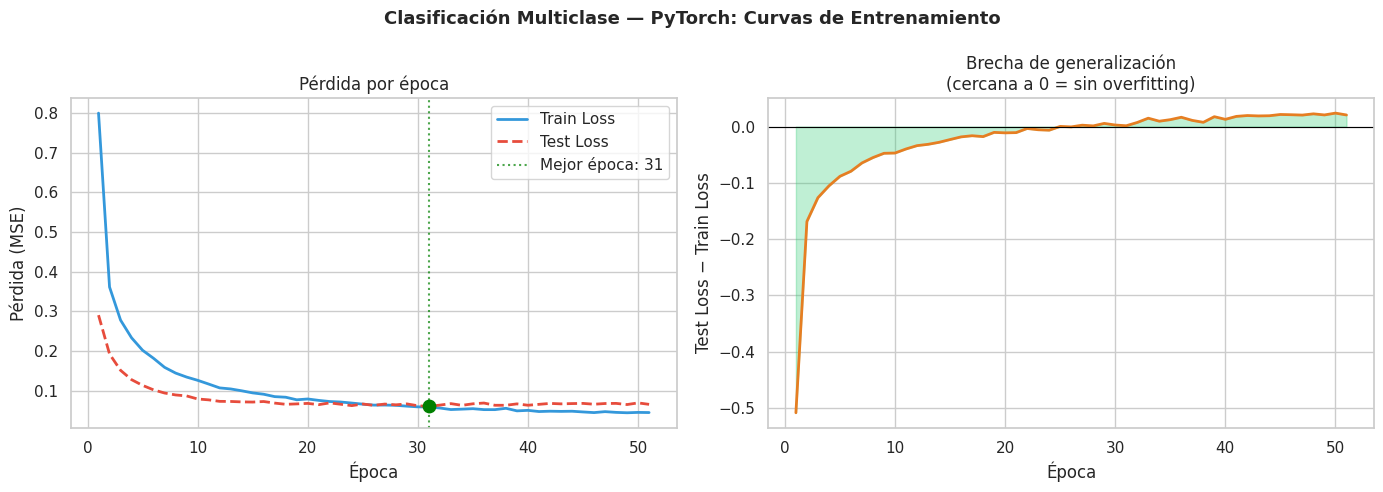

[Figura guardada: None]

   Interpretación:
   • Mejor época: 31
   • Mínima Test Loss: 0.0611
   • Brecha final: 0.0206 (✅ generalización OK)


In [65]:
class ClasificacionMulticlaseNet_PyTorch(nn.Module):
    def __init__(self, input_dim=int(X_train_flat.shape[1]), n_clases=N_CLASES, dropout_rate=0.3):
        super().__init__()
        self.red = nn.Sequential(

            # Capa oculta 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),  # normaliza las 128 activaciones del batch
            nn.ReLU(),            # introduce no-linealidad
            nn.Dropout(dropout_rate),  # apaga el 30% aleatoriamente en training

            # Capa oculta 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Capa de salida
            nn.Linear(64, n_clases)
        )

        # Inicialización He para todas las capas lineales
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        x: forma (batch_size, 30) → batch de artículos de noticias
        salida: forma (batch_size, 5) → 5 logits por artículo

        A diferencia de la red binaria que hacía .squeeze(1),
        aquí devolvemos el tensor 2D completo porque CrossEntropyLoss
        espera (batch_size, n_clases) como predicciones y (batch_size,)
        como etiquetas.
        """
        return self.red(x)   # logits, forma: (batch, n_clases)


# Instanciar
modelo_mc_pt = ClasificacionMulticlaseNet_PyTorch(784, N_CLASES, 0.3)
print(f"\n  Arquitectura PyTorch (Multiclase):")
print(modelo_mc_pt)
total_params_mc = sum(p.numel() for p in modelo_mc_pt.parameters() if p.requires_grad)
print(f"   Total de parámetros entrenables: {total_params_mc:,}")

# Entrenamiento
historial_mc_pt = entrenar_pytorch_clasificacion(
    modelo_mc_pt,
    X_train_norm, y_train_tensor,    
    X_test_norm,  y_test_tensor,
    epochs=300, batch_size=516, lr=1e-3, weight_decay=1e-4, patience=20
)

graficar_curvas(historial_mc_pt, 'Clasificación Multiclase — PyTorch: Curvas de Entrenamiento')

El gráfico de Pérdida por época nos permite ver como el entrenamiento se mantiene estable y como se logra conseguir una convergencia suave. Además, se observa una brecha de generalización cercana a 0, lo cual demuestra que el modelo aprendió a generalizar y no sufrió de sobreajuste. Puede ser que se vea en el gráfico (luego de la época Nº 30) un indicio del comienzo del sobreajuste en el modelo, puesto que la perdida de Train sigue bajando, mientras que la de Test comienza a empeorar. Posiblemente, al aumentar la cantidad de épocas, se conseguiría agravar este problema y se obtendría como resultado un modelo que memoriza, con incapacidad de generalizar. 

# Evaluación del modelo

En el siguiente código se utilizará classification report de Sklearn para evaluar el rendimiento del modelo. Esto garantiza que observemos una amplia gama de métricas por clase y globales para estar realmente seguros de que el modelo funciona correctamente. Si nos quedáramos solamente con una métrica global, como la accuracy, estaríamos prestando atención a los resultados del modelo en general en vez de ver como funciona cada clase individualmente, lo que podría causar que ignoremos erróneamente clases que podrían estar siendo mal clasificadas por el modelo. Igualmente, en este caso, al no ser tan grande el desbalance, la accuracy nos puede llegar a dar un indicativo bastante bueno del rendiemiento general del modelo, aunque siempre es pertinente revisar otras métricas por clase. 


 Evaluación PyTorch (Multiclase):
   Accuracy: 0.9803 (98.03%)

   Reporte por clase:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



/tmp/ipykernel_9296/4067344654.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


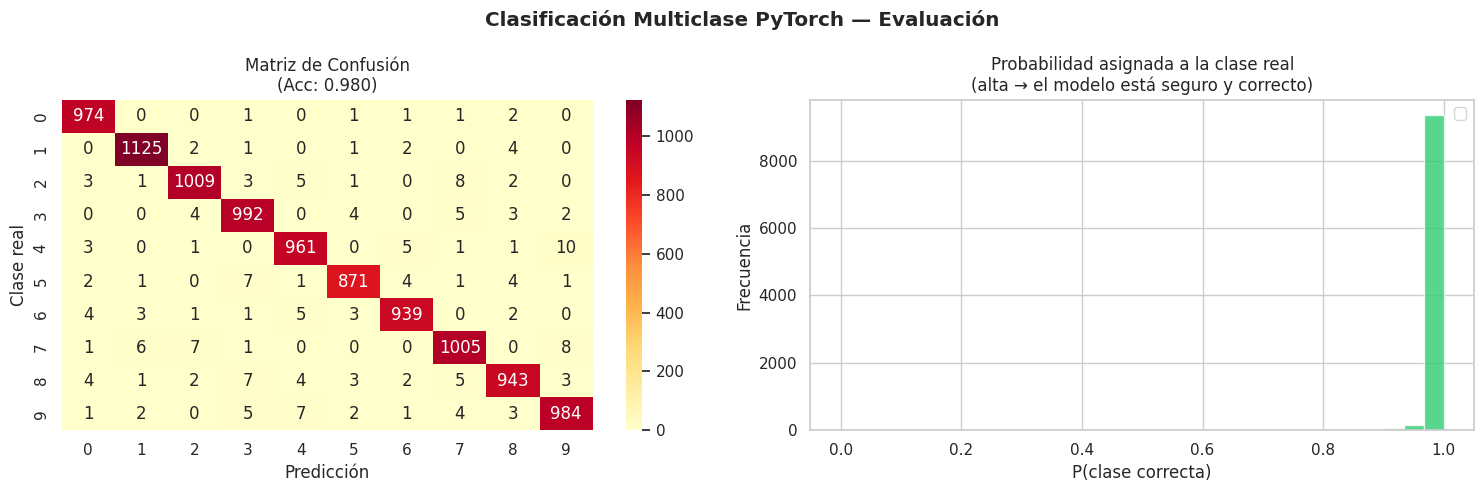

In [66]:
# Evaluación del modelo
modelo_mc_pt.eval()
with torch.no_grad():
    # La red devuelve logits de forma (n_test, 5)
    logits_mc = modelo_mc_pt(torch.tensor(X_test_norm, dtype=torch.float32))

    probs_mc  = torch.softmax(logits_mc, dim=1).numpy()

    preds_mc  = logits_mc.argmax(dim=1).numpy()

acc_mc = accuracy_score(y_test_tensor, preds_mc)
print(f"\n Evaluación PyTorch (Multiclase):")
print(f"   Accuracy: {acc_mc:.4f} ({acc_mc*100:.2f}%)")
print(f"\n   Reporte por clase:")

print(classification_report(y_test_tensor, preds_mc))

# Matriz de confusión multiclase
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Clasificación Multiclase PyTorch — Evaluación', fontweight='bold')

cm_mc = confusion_matrix(y_test_tensor, preds_mc)
sns.heatmap(cm_mc, annot=True, fmt='d', cmap='YlOrRd', xticklabels=[str(c) for c in range(N_CLASES)], yticklabels=range(0, 10), ax=axes[0])
axes[0].set_title(f'Matriz de Confusión\n(Acc: {acc_mc:.3f})')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Clase real')

# Probabilidades de la clase correcta
probs_correctas = [probs_mc[i, y_test_tensor[i]] for i in range(len(y_test_tensor))]
axes[1].hist(probs_correctas, bins=30, color='#2ecc71', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('P(clase correcta)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Probabilidad asignada a la clase real\n(alta → el modelo está seguro y correcto)')
axes[1].legend()

plt.tight_layout()
plt.show()

Las métricas para todos las clases son altamente satisfactorias, logrando superar el 0.95 en precisión, recall, f1-score y accuracy. En la matriz de confusión se observa también estos resultados casi perfectos, ya que se puede apreciar como la diagonal central está resaltada, dando indicio de que el modelo suele predecir la clase correcta. 

Total de errores: 197

Pares de dígitos con mayor confusión (Top 3):
  • Real: 4  →  Predicho: 9  (10 veces)
  • Real: 2  →  Predicho: 7  (8 veces)
  • Real: 7  →  Predicho: 9  (8 veces)

Imágenes clasificadas incorrectamente con mayor confianza:



/tmp/ipykernel_9296/513345433.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_true = np.array(y_test_tensor)


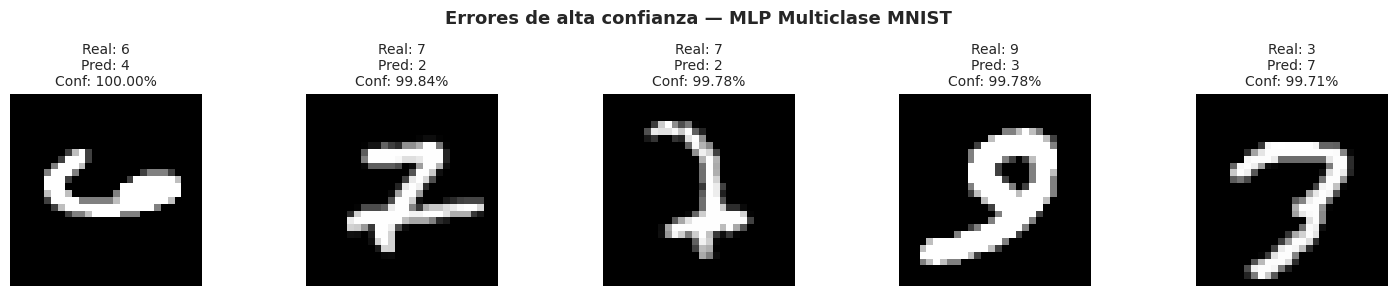

In [67]:
modelo_mc_pt.eval()
with torch.no_grad():
    logits    = modelo_mc_pt(torch.tensor(X_test_norm, dtype=torch.float32))
    probs_all = torch.softmax(logits, dim=1).numpy()
    y_pred    = logits.argmax(dim=1).numpy()
    max_probs = probs_all.max(axis=1)

y_true = np.array(y_test_tensor)


print(f"Total de errores: {(y_pred != y_true).sum()}\n")
print("Pares de dígitos con mayor confusión (Top 3):")

cm = confusion_matrix(y_true, y_pred)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

for _ in range(3):
    r, c = np.unravel_index(np.argmax(cm_off), cm_off.shape)
    print(f"  • Real: {r}  →  Predicho: {c}  ({cm_off[r, c]} veces)")
    cm_off[r, c] = 0


errores_idx     = np.where(y_pred != y_true)[0]
orden_conf      = np.argsort(max_probs[errores_idx])[::-1]
top5            = errores_idx[orden_conf[:5]]

print("\nImágenes clasificadas incorrectamente con mayor confianza:\n")
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("Errores de alta confianza — MLP Multiclase MNIST",
             fontsize=13, fontweight='bold')

for ax, idx in zip(axes, top5):
    img = X_test_norm[idx].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(
        f"Real: {y_true[idx]}\nPred: {y_pred[idx]}\nConf: {max_probs[idx]:.2%}",
        fontsize=10
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

El gráfico nos muestra varios números en donde el modelo predijo de manera errónea con una alta confianza. Como se puede ver en todos los casos, es evidente la razón por la que el modelo clasifica de manera errónea. todos los números tienen características particulares que se asemejan a otros, haciendo muy difícil para el clasificador de distinguir entre clases.

# Conclusión

El análisis y los resultados obtenidos a lo largo de este trabajo permiten concluir que los Perceptrones Multicapa (MLP) constituyen una arquitectura competente para la clasificación de dígitos escritos a mano en MNIST, alcanzando una accuracy del 98,07 % con solo **109.770 parámetros entrenables** distribuidos en dos capas ocultas (784→128→64→10). Sin embargo, este rendimiento notable no debe oscurecer las limitaciones estructurales fundamentales que presenta el MLP frente a datos de imagen: al aplanar cada imagen de 28×28 píxeles en un vector de 784 dimensiones, el modelo destruye por completo la información espacial y las relaciones de vecindad entre píxeles, tratando el píxel en la esquina superior izquierda como si fuera completamente independiente de su vecino inmediato. Esto se evidenció concretamente en el análisis de errores: los fallos más graves y con mayor confianza (>99%) ocurrieron precisamente en casos donde la caligrafía de un dígito compartía patrones de píxeles locales con otro (como el 7 cruzado confundido con el 2), confusiones que un humano resuelve de inmediato al leer la forma global y la estructura geométrica de la imagen. Además, a pesar de que el modelo usa regularización mediante BatchNorm y Dropout, la cantidad de parámetros crece cuadráticamente con la resolución de la imagen: si las imágenes fueran de 128×128 píxeles, la primera capa sola necesitaría más de 2 millones de parámetros, lo que hace al MLP intrínsecamente ineficiente y difícil de escalar. Estas limitaciones se resolverían de manera natural adoptando una **Red Neuronal Convolucional (CNN)**: mediante filtros locales de, por ejemplo, 3×3 píxeles con pesos compartidos, una CNN extrae automáticamente características espaciales jerárquicas (bordes → curvas → formas completas) sin importar su posición exacta en la imagen (invarianza a la traslación), y lo hace con una fracción de los parámetros; una arquitectura convolucional simple como LeNet-5, con apenas ~60.000 parámetros, supera sistemáticamente al MLP en MNIST con accuracies superiores al 99,2 %, y arquitecturas más modernas como ResNet o VGG, entrenadas sobre ImageNet, demuestran que este principio escala a problemas visuales de complejidad arbitraria, algo que los MLP no pueden lograr sin un crecimiento exponencial e inmanejable de parámetros.